This extends H_E_graph.ipynb to constrained problems

In [25]:
# imports
import itertools
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import joblib

# imports from qemcmc
from qemcmc.model import EnergyModel, ConstraintModel
from qemcmc.utils import ModelMaker
from qemcmc.sampler import QeProposal, ClassicalProposal
from qemcmc.coarse_grain import CoarseGraining


In [27]:

# Define parameters
n_spins = 8  # Number of spins in the system



In [28]:
# Initialise a random fully connected Ising model
#model  = ModelMaker(n_spins, "Fully Connected Ising", "example model").model
# Initialise a random fully connected Ising model
base_model  = ModelMaker(n_spins, "Fully Connected Ising", "example model").model

In [4]:


shape_of_J = (n_spins, n_spins)
J_constraint = np.zeros(shape_of_J)
#J_constraint[-2, -1] = 1
#J_constraint[-1, -2] = 1
for i in range(n_spins):
    for j in range(i+1, n_spins):
        u = np.random.uniform(0, 1)
        if u < 0.1:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1
# To ensure non-constant constraint
J_constraint[0,1] = 1
J_constraint[1,0] = 1
print("Constraint Couplings:\n", J_constraint)

def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]


    return sum == 0
constraint_model = ConstraintModel(n_spins, constraint_couplings = [J_constraint,], couplings = base_model.couplings, name="Constraint Model", cost_function_signs=base_model.cost_function_signs, constraint_func=constraint_checker_func, constraint_signs = [1,])




Constraint Couplings:
 [[0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0.]]
Could not find enough valid initial states satisfying the constraint. Please provide some manually if you want more than the ones found here. Found 46 valid states after 1000 attempts.


All energies:  [ -8.4374  -3.2068  -6.2176   0.659   -3.1996  -2.2598   0.4286   3.0144
  -5.608   -2.6854  -6.0474  -1.4788  -3.6022  -4.9704  -2.6332  -2.3554
   1.45     5.563    3.2058   8.9648   3.5166   3.3388   6.6808   8.149
   3.9722   5.7772   3.0688   6.5198   2.8068   0.321    3.3118   2.472
  -5.9818  -3.0492  -6.3464  -1.7678   0.4868  -0.8714   1.5306   1.8184
  -0.9916  -0.367   -4.0154  -1.7448   2.245   -1.4212   0.6296  -1.3906
   2.4424   4.2574   1.6138   5.0748   5.7398   3.264    6.3196   5.4898
   7.1254   6.6324   3.6376   4.7906   7.1908   2.407    5.1114   1.9736
  -3.2078  -1.044   -2.5068   1.303    2.3596   0.2326   4.469    3.988
  -2.5884  -2.7326  -4.5466  -3.0448  -0.253   -4.688   -0.8028  -3.5918
   3.5364   4.5826   3.7734   6.4656   5.9326   2.688    7.578    5.9794
   3.8486   2.5868   1.4264   1.8106   3.0128  -2.5398   1.999   -1.9076
  -0.3938  -0.528   -2.2772  -0.7654   6.4044   1.9794   5.9294   3.1504
   2.3864  -0.0558  -2.1562  -2.9524   

100%|██████████| 256/256 [00:01<00:00, 230.43it/s]


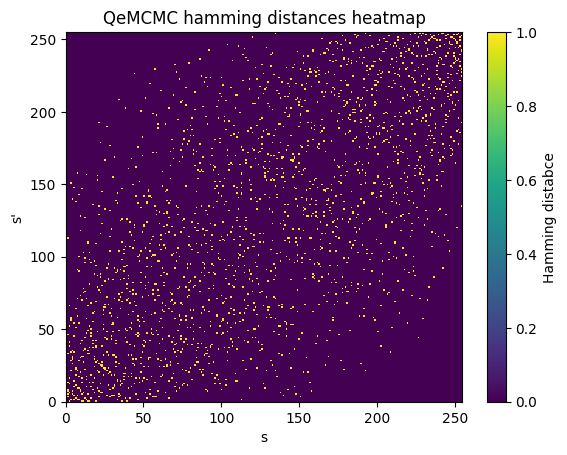

In [5]:
# (Classically) calculate energies of all configurations
all_energies = base_model.get_all_energies()


# (Classically) calculate the energy differences for all pairs of configurations
# And the Hamming distances for all pairs of configurations
S = base_model.S#np.array([np.binary_repr(s, width=n_spins) for s in range(2**n_spins)])
S_integer_arr = np.array([[int(bit) for bit in state] for state in S])
E_s = np.array(all_energies)
print("All energies: ", E_s)

E_unconstrained_order = np.argsort(E_s)
print("E_unconstrained_order: ", E_unconstrained_order)
E_s_constrained = np.array([E_s_ if constraint_checker_func(S[i]) else 1000 for i, E_s_ in enumerate(E_s)])
E_s_constrained_order = np.argsort(E_s_constrained)
number_valid_configs = np.sum(E_s_constrained < 99)
# find matrices of Energy differences of the configyurations, and hamming distances
E_diffs = np.zeros((2**n_spins, 2**n_spins))
hamming_dists = np.zeros((2**n_spins, 2**n_spins))
for s in S:
    for s_prime in S:
        hamming_dist = np.sum(np.bitwise_xor(S_integer_arr[int(s, 2)], S_integer_arr[int(s_prime, 2)]))
        E_diff = abs(E_s[int(s, 2)] - E_s[int(s_prime, 2)])
        E_diffs[int(s, 2), int(s_prime, 2)] = E_diff
        hamming_dists[int(s, 2), int(s_prime, 2)] = hamming_dist

E_order = np.argsort(E_s)

# plot the proposals between s and s', where the color is the haming distance

hamming_distances = np.zeros_like(E_diffs)
for i, s in enumerate(tqdm.tqdm(S)):
    for j, s_prime in enumerate(S):
        #if constraint_checker_func(s):
        hamming_distances[int(i),:] = np.sum(np.bitwise_xor(S_integer_arr[int(s, 2)], S_integer_arr), axis=1)
    hamming_distances_ordered = hamming_distances[E_order, :][:, E_order]
time = 5

#plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
#plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')

h_dists_flat = hamming_distances_ordered.flatten()
dist_1_flat = h_dists_flat
dist_1_flat[dist_1_flat>1.1] = 0

plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=dist_1_flat)#, norm="log")

plt.title("QeMCMC hamming distances heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Hamming distabce")
plt.show()





# Simulate classical proposals

Instead of using classical_mcmc, we quickly generate the proposal distruibutions manually

In [6]:
# # Now calculate the proposal probabilities for the classical MMCMC proposals

# # Uniform proposal probability is trivial
# uniform_weights = np.ones_like(E_diffs)
# row_sums = uniform_weights.sum(axis=1)
# uniform_weights = uniform_weights / row_sums[:, np.newaxis]



# # Local probability is also relatively simple
# local_weights = np.zeros_like(E_diffs)
# local_weights[np.isclose(hamming_dists, 1)] = 1

# # normalise
# row_sums = local_weights.sum(axis=1)
# local_weights = local_weights / row_sums[:, np.newaxis]


# 

# # Plot the proposal probabilities as a heatmap, ordered by energy
# uniform_weights_ordered = uniform_weights[E_order, :][:, E_order]
# # make the color graident logarithmic

# # draw lines demarking the invalid area:
# plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
# plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
# plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=uniform_weights_ordered.flatten(), norm="log")
# plt.title("Uniform proposal weights heatmap")
# # plt.xlabel("s")
# plt.ylabel("s'")
# plt.colorbar(label="Proposal weight")
# plt.show()


# local_weights_constrained_ordered = local_weights[E_s_constrained_order, :][:, E_s_constrained_order]
# plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
# plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
# plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=local_weights_constrained_ordered.flatten(), norm="log")
# plt.title("Local proposal weights heatmap constrained & ordered") 
# plt.xlabel("s")
# plt.ylabel("s'")
# plt.colorbar(label="Proposal weight")
# plt.show()


# local_weights_ordered = local_weights[E_order, :][:, E_order]
# plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=local_weights_ordered.flatten(), norm="log")
# plt.title("Local proposal weights heatmap") 
# plt.xlabel("s")
# plt.ylabel("s'")
# plt.colorbar(label="Proposal weight")
# plt.show()



100%|██████████| 256/256 [00:00<00:00, 523.66it/s]


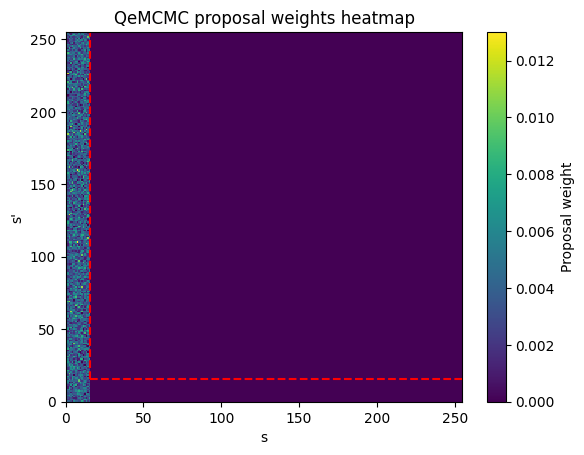

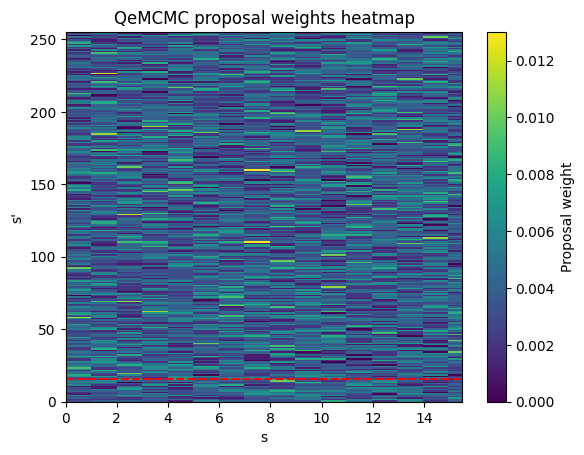

In [7]:
# How many times to sample each proposal
reps = 1000
# brute force method to get QeMCMC weights
uniform_proposal = ClassicalProposal(constraint_model,method = "uniform")
uniform_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = uniform_proposal.update(s)
            state_int = int(state, 2)
            uniform_weights_sample[i, state_int] += 1
uniform_weights_sample = uniform_weights_sample / (reps)
uniform_weights_sample_ordered = uniform_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic
plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=uniform_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()



plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=uniform_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

100%|██████████| 256/256 [00:00<00:00, 1701.75it/s]


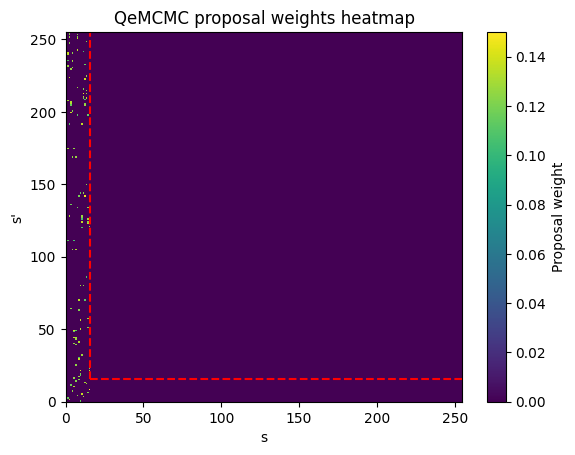

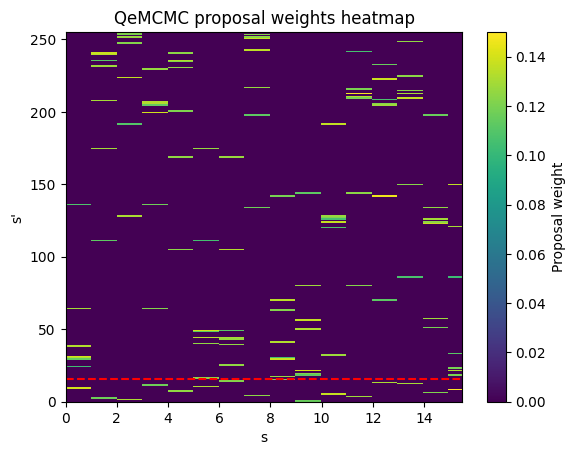

In [8]:
# How many times to sample each proposal
reps = 1000
# brute force method to get QeMCMC weights
local_proposal = ClassicalProposal(constraint_model,method = "local")
local_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = local_proposal.update(s)
            state_int = int(state, 2)
            local_weights_sample[i, state_int] += 1
local_weights_sample = local_weights_sample / (reps)
local_weights_sample_ordered = local_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic
plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=local_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()



plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=local_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

The uniform proposal of course has a very uniform distribution, while the local proposal has a sparse and structured distribution. Note that the configurations are ordered (on both axis) by their energy.

# Quantum-enhanced proposals

Lets see how the quantum proposal distribution looks. To do this, we first take samples using the qe_proposal class.

In [ ]:
print("len(constraint_model.couplings): ", len(constraint_model.couplings))
# QeMCMC parameters
gamma = 0.45
time = 10

len(constraint_model.couplings):  2


100%|██████████| 256/256 [00:04<00:00, 62.45it/s] 


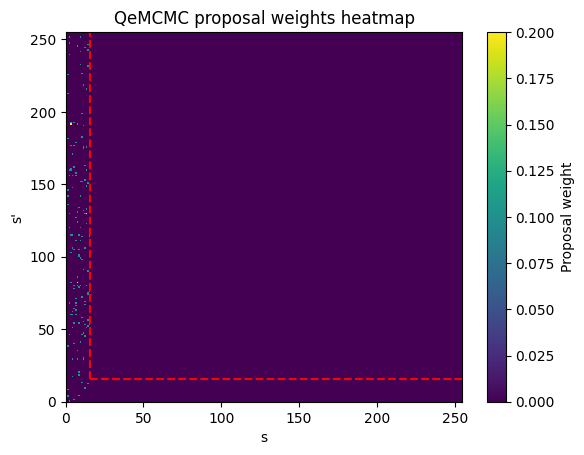

In [10]:
# How many times to sample each proposal
reps = 10
# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, coupling_weights=[0.1,0.1,(0.1,0.2)])
qemcmc_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = quantum_proposal.update(s)
            state_int = int(state, 2)
            qemcmc_weights_sample[i, state_int] += 1
qemcmc_weights_sample = qemcmc_weights_sample / (reps)

qemcmc_weights_sample_ordered = qemcmc_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic
plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()


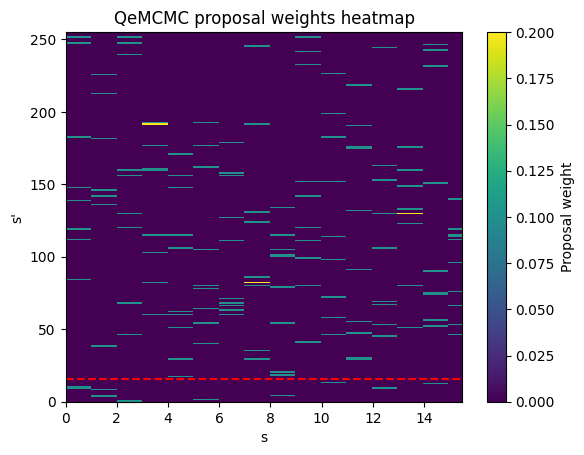

In [11]:
# NOw plot just the valid part of the x axis proposal matrix, ordered by energy.
# We do this as we only actually care about proposals from valid configurations

#plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

The distribution is very structured around the diagonal, suggesting proposals of small energy change are higher in probability. The graph is very sparse however, so lets extract exact statevectors so that we can better understand the proposal.

In [21]:

reps = 5
self_proposals_percent_list = []
invalid_proposals_percent_list = []
gamma_constrains = np.logspace(-1, np.log10(0.7),10)
weights_list = []

for gamma_constraint in gamma_constrains:
    qemcmc_weights_sample = np.zeros_like(E_diffs)

    prob_gamma = 0
    mixing_gamma = 1-(prob_gamma + gamma_constraint)
    weights = [prob_gamma, prob_gamma, gamma_constraint]
    quantum_proposal = QeProposal(constraint_model, gamma=mixing_gamma, time=time, coupling_weights=weights)
    for i, s in enumerate(tqdm.tqdm(S)):
        if constraint_checker_func(s):

            for j in range(reps):
                state = quantum_proposal.update(s)
                state_int = int(state, 2)
                qemcmc_weights_sample[i, state_int] += 1
    qemcmc_weights_sample = qemcmc_weights_sample / (reps)
    qemcmc_weights_sample = np.round(qemcmc_weights_sample, decimals=3)
    qemcmc_weights_sample_ordered = qemcmc_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]


    # plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
    # plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_ordered.flatten(), norm="log")
    # plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.xlim(-0.5, number_valid_configs-0.5)
    # plt.title("QeMCMC proposal weights heatmap")
    # plt.xlabel("s")
    # plt.ylabel("s'")
    # plt.colorbar(label="Proposal weight")
    # plt.show()
    # plt.show()
    self_proposals_percent = (100 * np.sum(np.diag(qemcmc_weights_sample))) / (number_valid_configs)

    # normalise
    row_sums = qemcmc_weights_sample.sum(axis=1)
    qemcmc_weights = qemcmc_weights_sample / row_sums[:, np.newaxis]
    #qemcmc_weights[np.diag_indices_from(qemcmc_weights)] = 0


    #print("violating proposals percent:", 100 * np.sum(qemcmc_weights_ordered[E_s_constrained<99, E_s_constrained>99]) / (number_valid_configs))

    M = 2**n_spins

    mid = number_valid_configs #M // 2
    weights_2d = qemcmc_weights_sample_ordered.reshape(M, M)
    top_left_sum = np.sum(weights_2d[:mid, mid:])
    bottom_right_sum = np.sum(weights_2d[mid:, :mid])
    total_sum = np.sum(weights_2d)

    # Calculate percentage
    percentage = ((top_left_sum + bottom_right_sum) / total_sum) * 100

    #print(f"Percentage Of invalid proposals quadrants: {percentage:.2f}%")

    self_proposals_percent_list.append(self_proposals_percent)
    invalid_proposals_percent_list.append(percentage)

    weights_list.append(qemcmc_weights_sample)
    


    

100%|██████████| 256/256 [00:01<00:00, 208.43it/s]


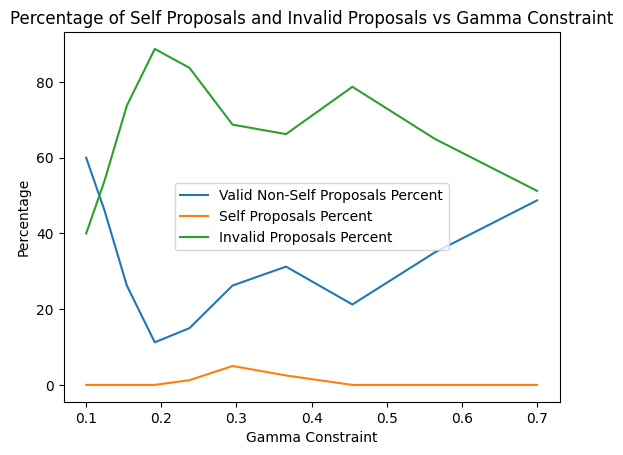

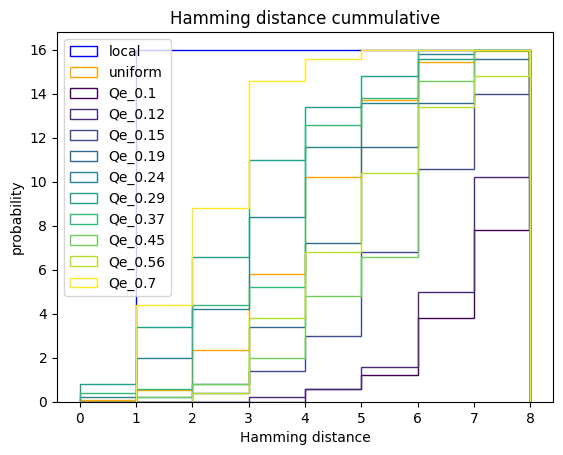

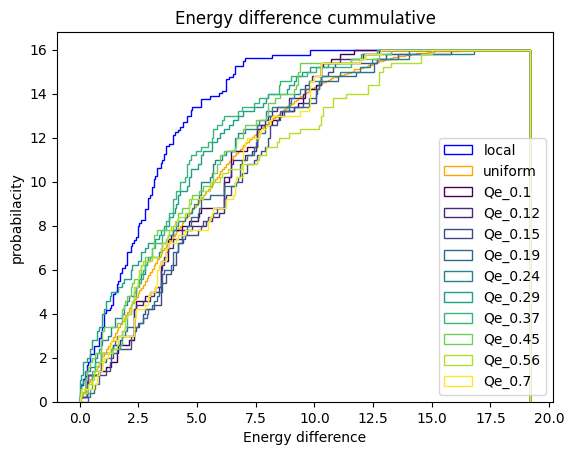

In [22]:

valid_non_self_proposals_percent_list = 100 - np.array(self_proposals_percent_list) - np.array(invalid_proposals_percent_list)
plt.plot(gamma_constrains, valid_non_self_proposals_percent_list, label="Valid Non-Self Proposals Percent")
plt.plot(gamma_constrains, self_proposals_percent_list, label="Self Proposals Percent")
plt.plot(gamma_constrains, invalid_proposals_percent_list, label="Invalid Proposals Percent")
plt.xlabel("Gamma Constraint")
plt.ylabel("Percentage")
plt.title("Percentage of Self Proposals and Invalid Proposals vs Gamma Constraint")
plt.legend()
plt.show()





# plot histograms of hamming distances
weights_list_ = [local_weights_sample, uniform_weights_sample] + weights_list
labels = ["local", "uniform"]+["Qe_"+str(np.round(lab,2)) for lab in gamma_constrains]
colors= ["blue", "orange"] + plt.cm.viridis(np.linspace(0, 1, len(gamma_constrains))).tolist()
for weights, label, color in zip(weights_list_, labels, colors):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend()
plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("probability")
plt.show()



# plot energy difference histograms 
for weights, label, color in zip(weights_list_, labels, colors):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
plt.legend()
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("probabilacity")
plt.show()

In [23]:
# Just to check the sampling method, make the same graph with sampling vs statevector

self_proposals_percent_list_state_vector = []
invalid_proposals_percent_list_state_vector = []
weights_list_state_vector = []

gamma_constrains = np.logspace(-1, np.log10(0.7),10)
for gamma_constraint in gamma_constrains:
    qemcmc_weights = np.zeros_like(E_diffs)
    for i, s in enumerate(tqdm.tqdm(S)):
        if constraint_checker_func(s):
            prob_gamma = 0
            mixing_gamma = 1-(prob_gamma + gamma_constraint)

            gammas = [prob_gamma, prob_gamma, gamma_constraint]

            
            
            probabilities = np.abs(quantum_proposal.CM.get_state_vector(s, gammas, time, mixing_gamma)) ** 2
            qemcmc_weights[int(i),:] += probabilities

            if np.any(np.isnan(probabilities)):  # Check for NaN values
                print("nan probabilities for state: ", s, " with gammas: ", gammas)

    qemcmc_weights = np.round(qemcmc_weights, decimals=3)
    qemcmc_weights_ordered = qemcmc_weights[E_s_constrained_order, :][:, E_s_constrained_order]


    # plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
    # plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_ordered.flatten(), norm="log")
    # plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.xlim(-0.5, number_valid_configs-0.5)
    # plt.title("QeMCMC proposal weights heatmap")
    # plt.xlabel("s")
    # plt.ylabel("s'")
    # plt.colorbar(label="Proposal weight")
    # plt.show()
    # plt.show()
    self_proposals_percent = (100 * np.sum(np.diag(qemcmc_weights))) / (number_valid_configs)

    


    #print("violating proposals percent:", 100 * np.sum(qemcmc_weights_ordered[E_s_constrained<99, E_s_constrained>99]) / (number_valid_configs))

    M = 2**n_spins

    mid = number_valid_configs #M // 2
    weights_2d = qemcmc_weights_ordered.reshape(M, M)
    top_left_sum = np.sum(weights_2d[:mid, mid:])
    bottom_right_sum = np.sum(weights_2d[mid:, :mid])
    total_sum = np.sum(weights_2d)

    # Calculate percentage
    percentage = ((top_left_sum + bottom_right_sum) / total_sum) * 100

    #print(f"Percentage Of invalid proposals quadrants: {percentage:.2f}%")

    self_proposals_percent_list_state_vector.append(self_proposals_percent)
    invalid_proposals_percent_list_state_vector.append(percentage)


    weights_list_state_vector.append(qemcmc_weights)


100%|██████████| 256/256 [00:00<00:00, 1183.42it/s]


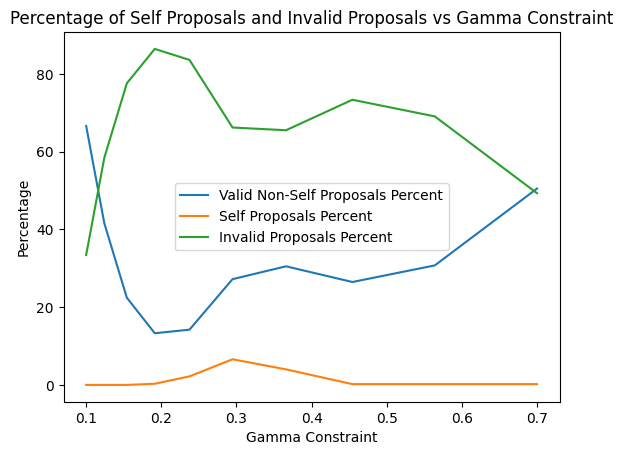

len(weights_list_state_vector):  [[0.    0.    0.    ... 0.027 0.025 0.545]
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.545 0.025 0.027 ... 0.    0.    0.   ]]


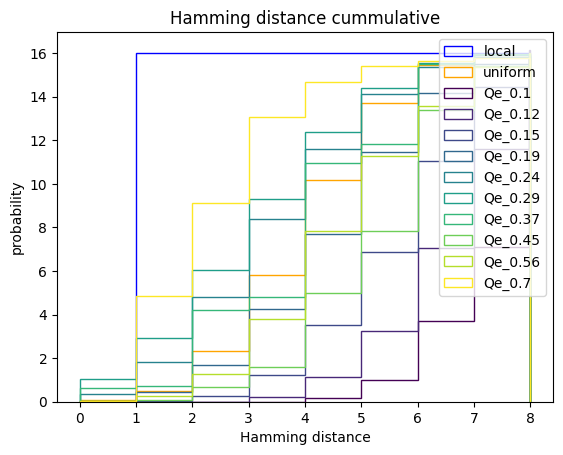

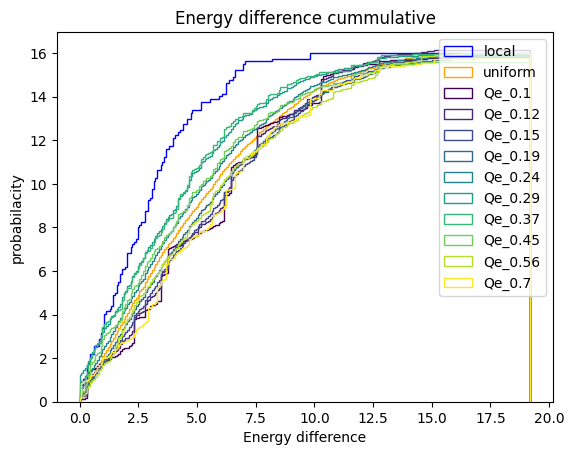

In [24]:

valid_non_self_proposals_percent_list_state_vector = 100 - np.array(self_proposals_percent_list_state_vector) - np.array(invalid_proposals_percent_list_state_vector)
plt.plot(gamma_constrains, valid_non_self_proposals_percent_list_state_vector, label="Valid Non-Self Proposals Percent")
plt.plot(gamma_constrains, self_proposals_percent_list_state_vector, label="Self Proposals Percent")
plt.plot(gamma_constrains, invalid_proposals_percent_list_state_vector, label="Invalid Proposals Percent")
plt.xlabel("Gamma Constraint")
plt.ylabel("Percentage")
plt.title("Percentage of Self Proposals and Invalid Proposals vs Gamma Constraint")
plt.legend()
plt.show()


print("len(weights_list_state_vector): ", weights_list_state_vector[0])


# plot histograms of hamming distances
weights_list_sv = [local_weights_sample, uniform_weights_sample] +    weights_list_state_vector
labels = ["local", "uniform"]+["Qe_"+str(np.round(lab,2)) for lab in gamma_constrains]
colors= ["blue", "orange"] + plt.cm.viridis(np.linspace(0, 1, len(gamma_constrains))).tolist()
for weights, label, color in zip(weights_list_sv, labels, colors):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend(loc = "upper right")

plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("probability")
plt.show()



# plot energy difference histograms 
for weights, label, color in zip(weights_list_sv, labels, colors):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
plt.legend(loc = "upper right")
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("probabilacity")
plt.show()

# Hamming weight plot

Plot cumulative hamming weight of each proposal to compare

In [16]:


row_sums_sample = qemcmc_weights_sample.sum(axis=1)
qemcmc_weights_sample = qemcmc_weights_sample / row_sums_sample[:, np.newaxis]

# plot histograms of hamming distances
weights_list = [local_weights, uniform_weights, qemcmc_weights_sample, qemcmc_weights]
labels = ["local", "uniform", "QeMCMC_sample", "QeMCMC"]
for weights, label in zip(weights_list, labels):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_hamming_dist")
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend()
plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("probability")
plt.show()



NameError: name 'local_weights' is not defined

# Energy difference plot

Plot cumulative hamming weight of proposals

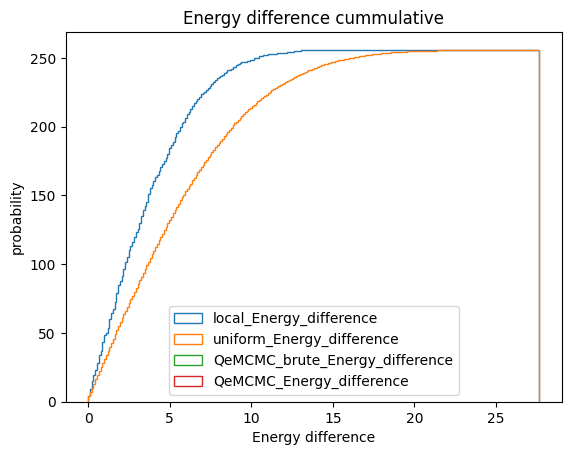

In [ ]:


# plot energy difference histograms 
for weights, label in zip(weights_list, labels):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_Energy_difference")
plt.legend()
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("probabilacity")
plt.show()

# Bonus - NOT UPDATED YET

Recreating the same graphs, but with coarse graining. This is a lot harder to do while "cheating" with the statevector approach, so instead we will just sample.



In [ ]:
# How many times to sample each proposal
reps = 10

# 2 sub groups
m = 2
print("maximum qubits used:", np.ceil(n_spins / m))

# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, m = m)
qemcmc_weights_sample_2 = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    for j in range(reps):
        state = quantum_proposal.update(s)
        state_int = int(state, 2)
        qemcmc_weights_sample_2[i, state_int] += 1
qemcmc_weights_sample_2 = qemcmc_weights_sample_2 / (reps)

qemcmc_weights_sample_ordered_2 = qemcmc_weights_sample_2[E_order, :][:, E_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_sample_ordered_2.flatten(), norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

maximum qubits used: 4.0


  0%|          | 0/256 [00:00<?, ?it/s]


WireError: Cannot run circuit(s) on lightning.qubit as they contain wires not found on the device: {4, 5, 6, 7}

maximum qubits used: 2.0


100%|██████████| 64/64 [00:12<00:00,  4.92it/s]


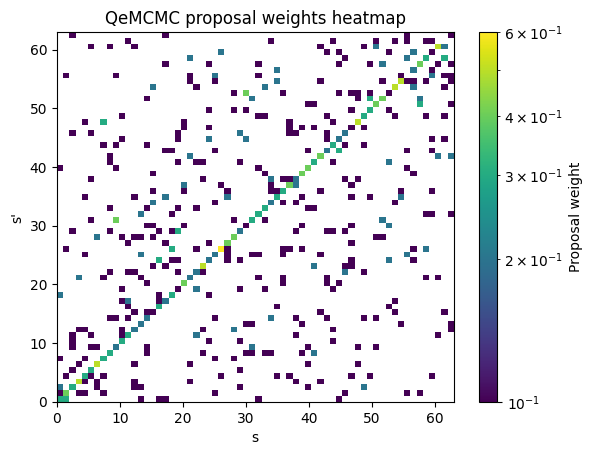

In [ ]:
# How many times to sample each proposal
reps = 10

# 4 sub groups
m = 4
print("maximum qubits used:", np.ceil(n_spins / m))

# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, m = m)
qemcmc_weights_sample_3 = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    for j in range(reps):
        state = quantum_proposal.update(s)
        state_int = int(state, 2)
        qemcmc_weights_sample_3[i, state_int] += 1
qemcmc_weights_sample_3 = qemcmc_weights_sample_3 / (reps)

qemcmc_weights_sample_ordered_2 = qemcmc_weights_sample_3[E_order, :][:, E_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_sample_ordered_2.flatten(), norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

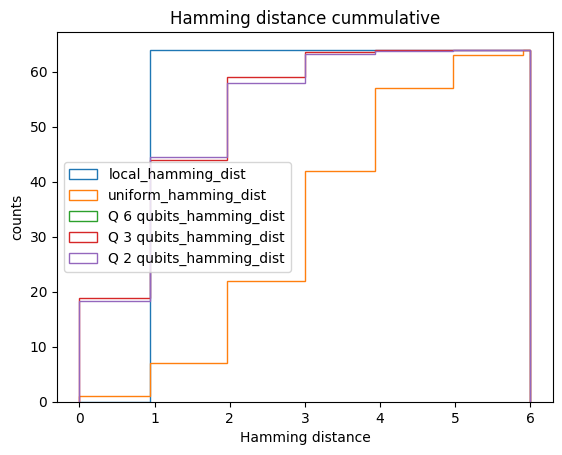

In [ ]:
cg_weights_list = [local_weights, uniform_weights, qemcmc_weights_sample, qemcmc_weights_sample_2, qemcmc_weights_sample_3]
cg_labels = ["local", "uniform", f"Q {n_spins} qubits", f"Q {int(np.ceil(n_spins/2))} qubits", f"Q {int(np.ceil(n_spins/4))} qubits"]

for weights, label in zip(cg_weights_list, cg_labels):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_hamming_dist")
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend()
plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("counts")
plt.show()

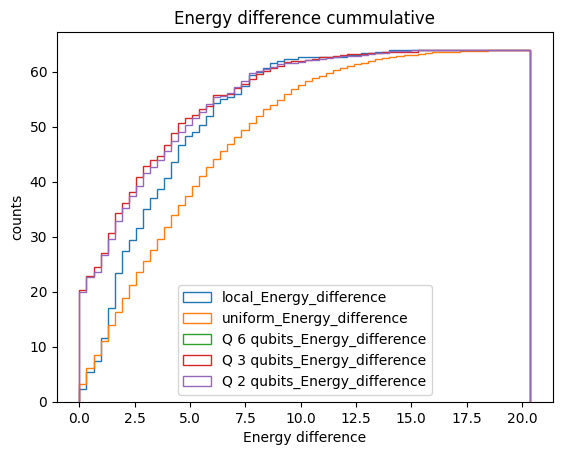

In [ ]:



# plot energy difference histograms with area under curve for each method
for weights, label in zip(cg_weights_list, cg_labels):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_Energy_difference")
plt.legend()
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("counts")
plt.show()